In [1]:
import pickle
import pandas as pd
import numpy as np
from scipy.sparse import load_npz
from pathlib import Path
import matplotlib.pyplot as plt


plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

BASE = Path.cwd().parent  # 按你实际路径修改

with open(BASE / 'artifacts_small.pkl', 'rb') as f:
    artifacts = pickle.load(f)

cat_transactions  = artifacts['cat_transactions']
item_transactions = artifacts['item_transactions']
user_cluster      = artifacts['user_cluster']

print(f'Category 事务数：{len(cat_transactions):,}')
print(f'Item 事务数    ：{len(item_transactions):,}')

Category 事务数：371,250
Item 事务数    ：276,261


In [2]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# TransactionEncoder 要求输入是 list of lists
te = TransactionEncoder()
te_array = te.fit_transform(cat_transactions['categories'].tolist())
cat_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'事务矩阵维度：{cat_df.shape}')
print(f'品类数      ：{cat_df.shape[1]}')
print()

# min_support=0.002 → 至少出现在 371,250 × 0.002 ≈ 743 条事务中
# 这个阈值保证规则有足够样本支撑，不会是偶然共现
CAT_MIN_SUPPORT = 0.002

cat_freq = fpgrowth(
    cat_df,
    min_support=CAT_MIN_SUPPORT,
    use_colnames=True,
    max_len=2          # 只挖掘 1-itemset 和 2-itemset，推荐场景够用且速度快
)

print(f'频繁项集数（support≥{CAT_MIN_SUPPORT}）：{len(cat_freq):,}')
print(cat_freq.sort_values('support', ascending=False).head())

事务矩阵维度：(371250, 6703)
品类数      ：6703

频繁项集数（support≥0.002）：391
     support              itemsets
21  0.058141  frozenset({1464116})
22  0.056361  frozenset({2735466})
4   0.052808  frozenset({4145813})
0   0.047521  frozenset({2885642})
5   0.045145  frozenset({4801426})


In [3]:
# 从频繁项集生成关联规则
cat_rules = association_rules(
    cat_freq,
    metric='lift',
    min_threshold=1.0       # Lift > 1 才是正相关，即 A 和 B 同时出现不是随机的
)

# 进一步筛选：confidence 也要有一定保证
cat_rules = cat_rules[cat_rules['confidence'] >= 0.1].copy()

# 只保留 antecedents 和 consequents 各为单个品类（1→1 规则，最好落地）
cat_rules = cat_rules[
    cat_rules['antecedents'].apply(len) == 1
].copy()
cat_rules['antecedent']  = cat_rules['antecedents'].apply(lambda x: list(x)[0])
cat_rules['consequent']  = cat_rules['consequents'].apply(lambda x: list(x)[0])

# 按 Lift 降序排列
cat_rules = cat_rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']] \
                .sort_values('lift', ascending=False) \
                .reset_index(drop=True)

print(f'关联规则总数（Lift≥1, Confidence≥0.1）：{len(cat_rules):,}')
print()
print('── Top 20 强关联规则（按 Lift）──')
print(cat_rules.head(20).to_string(index=False))

关联规则总数（Lift≥1, Confidence≥0.1）：43

── Top 20 强关联规则（按 Lift）──
 antecedent  consequent  support  confidence     lift
    2578647     2640118 0.002861    0.262741 8.899067
    2640118     3738615 0.003238    0.109662 6.542157
    3738615     2640118 0.003238    0.193154 6.542157
    1879194     1029459 0.002300    0.111039 5.860561
    1029459     1879194 0.002300    0.121410 5.860561
    1299190     1879194 0.002397    0.104990 5.067940
    1879194     1299190 0.002397    0.115720 5.067940
    2885642     4159072 0.006613    0.139157 4.973226
    4159072     2885642 0.006613    0.236330 4.973226
    1029459     1299190 0.002104    0.111032 4.862649
     149192     1320293 0.002432    0.126047 4.200620
     149192      982926 0.002990    0.154941 3.654510
    2355072     1320293 0.002120    0.100781 3.358618
    1320293      982926 0.004237    0.141203 3.330468
    2355072      982926 0.002914    0.138558 3.268087
    2465336     4801426 0.003197    0.143844 3.186280
    1320293     48014

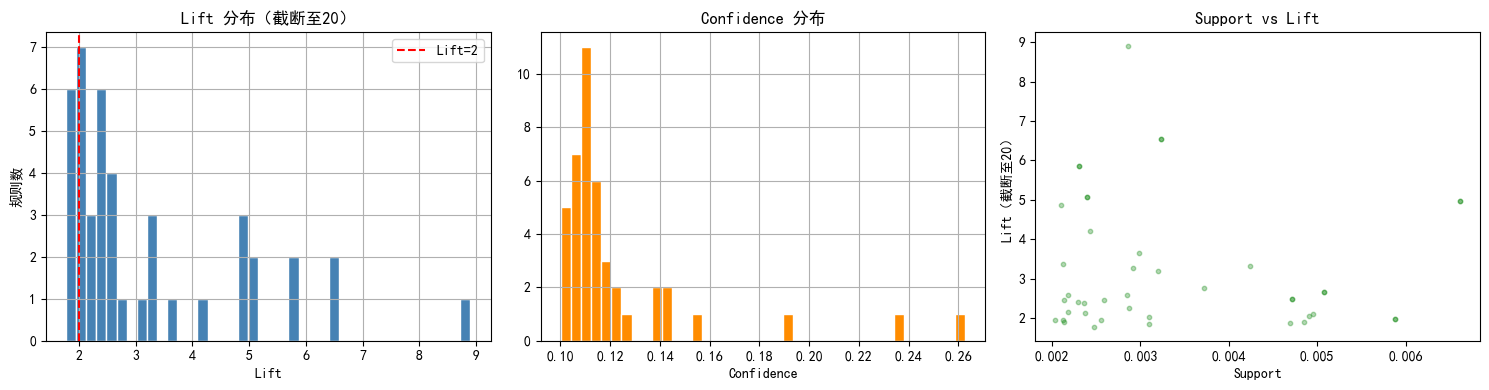

Lift > 2  的规则数：33
Lift > 5  的规则数：7
Lift > 10 的规则数：0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Lift 分布
cat_rules['lift'].clip(upper=20).hist(
    bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Lift 分布（截断至20）')
axes[0].set_xlabel('Lift')
axes[0].set_ylabel('规则数')
axes[0].axvline(x=2, color='red', linestyle='--', label='Lift=2')
axes[0].legend()

# 2. Confidence 分布
cat_rules['confidence'].hist(
    bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Confidence 分布')
axes[1].set_xlabel('Confidence')

# 3. Support vs Lift 散点图
axes[2].scatter(
    cat_rules['support'],
    cat_rules['lift'].clip(upper=20),
    alpha=0.3, s=10, color='green')
axes[2].set_title('Support vs Lift')
axes[2].set_xlabel('Support')
axes[2].set_ylabel('Lift（截断至20）')

plt.tight_layout()
plt.show()

# 高质量规则统计
print(f'Lift > 2  的规则数：{(cat_rules["lift"] > 2).sum():,}')
print(f'Lift > 5  的规则数：{(cat_rules["lift"] > 5).sum():,}')
print(f'Lift > 10 的规则数：{(cat_rules["lift"] > 10).sum():,}')

In [5]:
# ── Item 级 FP-Growth 可行性评估 ──
from collections import Counter

ITEM_MIN_SUPPORT  = 0.001
n_transactions    = len(item_transactions)
min_count         = int(np.ceil(ITEM_MIN_SUPPORT * n_transactions))

item_doc_freq = Counter(
    item for items in item_transactions['items'] for item in items
)

valid_items_count = sum(1 for cnt in item_doc_freq.values() if cnt >= min_count)
avg_doc_freq      = np.mean(list(item_doc_freq.values()))

print('── Item 级关联规则可行性评估 ──')
print(f'事务总数                    ：{n_transactions:,}')
print(f'唯一商品数                  ：{len(item_doc_freq):,}')
print(f'平均每商品出现事务数         ：{avg_doc_freq:.2f}')
print(f'min_support={ITEM_MIN_SUPPORT} 对应最低出现次数：{min_count}')
print(f'达到频繁阈值的商品数         ：{valid_items_count}')
print()
print('结论：item 级购买行为过于分散，平均每商品仅出现在极少事务中')
print('      无论如何调整 min_support，要么商品数不足（规则无意义），')
print('      要么矩阵过大（内存爆炸）')
print()
print('✅ 放弃 item 级关联规则')
print('   item 层推荐改用两阶段策略：CF 推荐目标品类 → 品类内按热度选具体商品')

item_rules = pd.DataFrame()   # 空 DataFrame，保持后续代码结构一致

── Item 级关联规则可行性评估 ──
事务总数                    ：276,261
唯一商品数                  ：137,918
平均每商品出现事务数         ：6.49
min_support=0.001 对应最低出现次数：277
达到频繁阈值的商品数         ：18

结论：item 级购买行为过于分散，平均每商品仅出现在极少事务中
      无论如何调整 min_support，要么商品数不足（规则无意义），
      要么矩阵过大（内存爆炸）

✅ 放弃 item 级关联规则
   item 层推荐改用两阶段策略：CF 推荐目标品类 → 品类内按热度选具体商品


In [6]:
# 把聚类标签合并到事务集
buy_raw_cluster = pd.read_csv(
    Path.cwd().parent /'buy_records.csv',
    usecols=['user_id', 'category_id'],
    dtype={'user_id': 'int32', 'category_id': 'int32'}
).merge(user_cluster, on='user_id', how='inner')

cluster_rules = {}   # 存储每个簇的规则

CLUSTER_MIN_SUPPORT = 0.003  # 簇内事务更少，可以略微提高以保证规则质量

for cluster_id in sorted(user_cluster['cluster'].unique()):
    cluster_users = user_cluster[user_cluster['cluster'] == cluster_id]['user_id']

    # 构建该簇的事务集
    cluster_buy = buy_raw_cluster[buy_raw_cluster['user_id'].isin(cluster_users)]
    cluster_trans = (
        cluster_buy.groupby('user_id')['category_id']
                   .apply(lambda x: list(x.unique()))
                   .reset_index(name='categories')
    )
    cluster_trans = cluster_trans[cluster_trans['categories'].apply(len) >= 2]

    if len(cluster_trans) < 100:
        print(f'簇 {cluster_id}：事务数不足（{len(cluster_trans)}），跳过')
        continue

    # FP-Growth
    te_c = TransactionEncoder()
    te_c_array = te_c.fit_transform(cluster_trans['categories'].tolist())
    c_df = pd.DataFrame(te_c_array, columns=te_c.columns_)

    c_freq = fpgrowth(c_df, min_support=CLUSTER_MIN_SUPPORT,
                      use_colnames=True, max_len=2)

    if len(c_freq) == 0:
        print(f'簇 {cluster_id}：无频繁项集，尝试降低 support')
        continue

    c_rules = association_rules(c_freq, metric='lift', min_threshold=1.0)
    c_rules = c_rules[c_rules['confidence'] >= 0.1].copy()
    c_rules = c_rules[c_rules['antecedents'].apply(len) == 1].copy()
    c_rules['antecedent'] = c_rules['antecedents'].apply(lambda x: list(x)[0])
    c_rules['consequent'] = c_rules['consequents'].apply(lambda x: list(x)[0])
    c_rules = c_rules[['antecedent','consequent','support','confidence','lift']] \
                  .sort_values('lift', ascending=False).reset_index(drop=True)

    cluster_rules[cluster_id] = c_rules
    print(f'簇 {cluster_id}：事务 {len(cluster_trans):,} 条 → 规则 {len(c_rules):,} 条，'
          f'Top Lift = {c_rules["lift"].max():.2f}')

print()
print(f'成功挖掘规则的簇数：{len(cluster_rules)} / {user_cluster["cluster"].nunique()}')

簇 0：事务 731 条 → 规则 14 条，Top Lift = 20.31
簇 1：事务 62,456 条 → 规则 79 条，Top Lift = 12.09
簇 2：事务 60,802 条 → 规则 17 条，Top Lift = 4.54
簇 3：事务 33,760 条 → 规则 3 条，Top Lift = 6.34
簇 4：事务 50,755 条 → 规则 29 条，Top Lift = 6.63
簇 5：事务 162,767 条 → 规则 13 条，Top Lift = 6.28

成功挖掘规则的簇数：6 / 6


In [7]:
import pickle
from pathlib import Path

BASE = Path.cwd().parent  # 按你实际路径修改

with open(BASE / 'artifacts_small.pkl', 'rb') as f:
    artifacts = pickle.load(f)

artifacts['cat_rules']     = cat_rules
artifacts['item_rules']    = item_rules
artifacts['cluster_rules'] = cluster_rules

with open(BASE / 'artifacts_small.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('✅ Step 2 完成，关联规则已保存至 artifacts_small.pkl')
print()
print('── 结果汇总 ──')
print(f'  Category 级规则数：{len(cat_rules):,}')
print(f'  Item 级规则数    ：{len(item_rules):,}')
print(f'  分簇规则（各簇） ：', {k: len(v) for k, v in cluster_rules.items()})

✅ Step 2 完成，关联规则已保存至 artifacts_small.pkl

── 结果汇总 ──
  Category 级规则数：43
  Item 级规则数    ：0
  分簇规则（各簇） ： {np.int8(0): 14, np.int8(1): 79, np.int8(2): 17, np.int8(3): 3, np.int8(4): 29, np.int8(5): 13}
